# Maestría en Inteligencia Artificial — Aprendizaje No Supervisado
## Análisis Comparativo de Modelos de Clustering sobre Datos Educativos (UNESCO)

---

| Elemento | Detalle |
|---|---|
| **Dataset** | `datos_educativos.csv` — Indicadores UNESCO globales |
| **Pregunta de investigación** | *¿Es posible identificar grupos naturales de países con perfiles educativos similares, y cómo difieren los patrones encontrados según el método de aprendizaje no supervisado utilizado?* |
| **Modelos** | K-Means · DBSCAN · PCA · t-SNE |
| **Cobertura** | 210 países · 2000–2022 · 3 niveles educativos · 2 géneros |
| **Fuente** | UNESCO Institute for Statistics (UIS), acceso abril 2023 |

---

## 0. Fundamentos: ¿Por qué aprendizaje no supervisado?

A diferencia del aprendizaje supervisado, aquí **no existe una variable objetivo predefinida**.  
El objetivo es descubrir estructura latente en los datos: agrupaciones, patrones ocultos y relaciones no evidentes.

| Característica | Supervisado | No Supervisado (este proyecto) |
|---|---|---|
| Variable objetivo | Sí (etiquetas conocidas) | No existe |
| Objetivo | Predecir / clasificar | Descubrir estructura |
| Validación | Accuracy, F1, AUC | Silhouette, Davies-Bouldin, Calinski-Harabasz |
| Algoritmos | Decision Tree, SVM, XGBoost | K-Means, DBSCAN, PCA, t-SNE |

**Justificación del dataset:** Las tasas de matrícula por género y nivel educativo ofrecen un perfil multidimensional  
de cada país. Agrupar esos perfiles sin etiquetas externas permite descubrir tipologías educativas globales  
basadas únicamente en los datos.


---
## 1. Carga de Librerías y Configuración del Entorno


In [1]:
# ══════════════════════════════════════════════════════════════════
# 1. LIBRERÍAS Y CONFIGURACIÓN GLOBAL
# ══════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import shapiro
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

# ── Estilo global de gráficos (lo tomamos del trabajo realizado anteriormente para la maestría) ──
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi']    = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print("✓ Entorno configurado correctamente.")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")
import sklearn; print(f"  sklearn : {sklearn.__version__}")


✓ Entorno configurado correctamente.
  pandas  : 2.3.3
  numpy   : 2.3.5
  sklearn : 1.7.2


---
## 2. Carga del Dataset


In [2]:
# ══════════════════════════════════════════════════════════════════
# 2. CARGA DEL DATASET
# ══════════════════════════════════════════════════════════════════

df_raw = pd.read_csv('datos_educativos.csv')

print(f"{'='*55}")
print(f"  INFORMACIÓN GENERAL DEL DATASET ORIGINAL")
print(f"{'='*55}")
print(f"  Dimensiones     : {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
print(f"  Países únicos   : {df_raw['Pais'].nunique()}")
print(f"  Años            : {df_raw['Año'].min()} – {df_raw['Año'].max()}")
print(f"  Indicadores     : {df_raw['Tipo de Dato Educativo'].nunique()}")
print(f"  Valores nulos   : {df_raw.isnull().sum().sum()}")
print(f"{'='*55}")

print("\nIndicadores disponibles:")
for ind in df_raw['Tipo de Dato Educativo'].unique():
    print(f"  • {ind}")

print("\nPrimeras filas:")
df_raw.head(6)


  INFORMACIÓN GENERAL DEL DATASET ORIGINAL
  Dimensiones     : 5,765 filas × 7 columnas
  Países únicos   : 210
  Años            : 2000 – 2022
  Indicadores     : 9
  Valores nulos   : 0

Indicadores disponibles:
  • Tasa Matrícula Primaria (Hombres)
  • Tasa Matrícula Primaria (Mujeres)
  • Tasa Matrícula Sec. Baja (Hombres)
  • Tasa Matrícula Sec. Baja (Mujeres)
  • Tasa Matrícula Sec. Alta (Hombres)
  • Tasa Matrícula Sec. Alta (Mujeres)
  • Estudiantes Secundaria Alta (miles)
  • Estudiantes Primaria (miles)
  • Estudiantes Secundaria Baja (miles)

Primeras filas:


,Índice,ID,Pais,Año,Tipo de Dato Educativo,Tasa,Fuente Datos
0,432,53,Australia and New Zealand,2005,Tasa Matrícula Primaria (Hombres),101.7,"""United Nations Educational, Scientific and Cu..."
1,433,53,Australia and New Zealand,2005,Tasa Matrícula Primaria (Mujeres),102.9,"""United Nations Educational, Scientific and Cu..."
2,435,53,Australia and New Zealand,2005,Tasa Matrícula Sec. Baja (Hombres),114.3,"""United Nations Educational, Scientific and Cu..."
3,436,53,Australia and New Zealand,2005,Tasa Matrícula Sec. Baja (Mujeres),116.2,"""United Nations Educational, Scientific and Cu..."
4,438,53,Australia and New Zealand,2005,Tasa Matrícula Sec. Alta (Hombres),212.6,"""United Nations Educational, Scientific and Cu..."
5,439,53,Australia and New Zealand,2005,Tasa Matrícula Sec. Alta (Mujeres),203.7,"""United Nations Educational, Scientific and Cu..."


---
## 3. Preprocesamiento — Construcción del Dataset para Clustering

### 3.1 Justificación de la transformación

El dataset original está en **formato largo** (*long format*): cada fila es una observación  
(país × año × indicador). Para aplicar algoritmos de clustering necesitamos **formato ancho** (*wide format*):  
cada fila = un país y cada columna = una característica numérica.

**Decisiones metodológicas:**

1. **Features seleccionadas:** Las 6 tasas de matrícula por género y nivel (Primaria, Sec. Baja, Sec. Alta). Se excluyen los indicadores de *estudiantes en miles* porque son magnitudes absolutas que dependen del tamaño del país, no de su cobertura educativa.
2. **Agregación temporal:** Se calcula la **media por país** sobre todos los años disponibles, maximizando la cobertura geográfica y suavizando fluctuaciones anuales.
3. **Umbral de calidad:** Se retienen solo países con **al menos 4 de 6 features** disponibles.
4. **Imputación:** Los valores faltantes restantes se imputan con la **mediana global** de cada feature.


In [3]:
# ══════════════════════════════════════════════════════════════════
# 3.1 SELECCIÓN DE INDICADORES — Solo tasas de matrícula (no volúmenes)
# ══════════════════════════════════════════════════════════════════

TASAS = [
    'Tasa Matrícula Primaria (Hombres)',
    'Tasa Matrícula Primaria (Mujeres)',
    'Tasa Matrícula Sec. Baja (Hombres)',
    'Tasa Matrícula Sec. Baja (Mujeres)',
    'Tasa Matrícula Sec. Alta (Hombres)',
    'Tasa Matrícula Sec. Alta (Mujeres)',
]

df_tasas = df_raw[df_raw['Tipo de Dato Educativo'].isin(TASAS)].copy()

# ── Pivot: País × Indicador, promediando sobre todos los años ──
df_pivot = (
    df_tasas
    .groupby(['Pais', 'Tipo de Dato Educativo'])['Tasa']
    .mean()
    .unstack('Tipo de Dato Educativo')
    .reset_index()
)
df_pivot.columns.name = None

# Renombrar columnas a nombres cortos para visualización
COL_MAP = {
    'Tasa Matrícula Primaria (Hombres)' : 'Prim_H',
    'Tasa Matrícula Primaria (Mujeres)' : 'Prim_M',
    'Tasa Matrícula Sec. Baja (Hombres)': 'SecBaja_H',
    'Tasa Matrícula Sec. Baja (Mujeres)': 'SecBaja_M',
    'Tasa Matrícula Sec. Alta (Hombres)': 'SecAlta_H',
    'Tasa Matrícula Sec. Alta (Mujeres)': 'SecAlta_M',
}
df_pivot = df_pivot.rename(columns=COL_MAP)
FEATURES = list(COL_MAP.values())

# ── Filtro de calidad: al menos 4/6 features con datos ──
df_pivot['n_features_ok'] = df_pivot[FEATURES].notna().sum(axis=1)
n_antes = len(df_pivot)
df_pivot = df_pivot[df_pivot['n_features_ok'] >= 4].copy()
n_despues = len(df_pivot)

# ── Imputación con mediana global de cada feature ──
for col in FEATURES:
    mediana = df_pivot[col].median()
    df_pivot[col] = df_pivot[col].fillna(mediana)

print(f"{'='*55}")
print(f"  DATASET PARA CLUSTERING (FORMATO ANCHO)")
print(f"{'='*55}")
print(f"  Países antes del filtro  : {n_antes}")
print(f"  Países eliminados        : {n_antes - n_despues} (< 4 features)")
print(f"  Países finales           : {n_despues}")
print(f"  Features (columnas)      : {len(FEATURES)}")
print(f"  Valores nulos restantes  : {df_pivot[FEATURES].isnull().sum().sum()}")
print(f"{'='*55}")
print("\nPrimeras filas del dataset de trabajo:")
df_pivot[['Pais'] + FEATURES].head(8)


  DATASET PARA CLUSTERING (FORMATO ANCHO)
  Países antes del filtro  : 208
  Países eliminados        : 1 (< 4 features)
  Países finales           : 207
  Features (columnas)      : 6
  Valores nulos restantes  : 0

Primeras filas del dataset de trabajo:


,Pais,Prim_H,Prim_M,SecBaja_H,SecBaja_M,SecAlta_H,SecAlta_M
0,"""China, Hong Kong SAR""",105.450,108.600,104.625000,104.100000,88.000000,87.700
1,"""China, Macao SAR""",99.350,96.425,108.700000,103.025000,82.700000,82.975
2,Afghanistan,123.140,80.840,75.220000,41.480000,41.300000,19.575
3,Albania,98.175,99.725,96.325000,98.125000,83.850000,80.050
4,Algeria,116.020,109.620,126.933333,117.833333,48.033333,68.300
5,Angola,116.160,94.340,46.975000,31.675000,26.066667,17.000
6,Anguilla,115.260,113.420,107.825000,106.900000,103.800000,101.625
7,Antigua and Barbuda,108.200,104.025,118.525000,107.425000,81.533333,101.700


In [4]:
# ══════════════════════════════════════════════════════════════════
# 3.2 ESTANDARIZACIÓN — StandardScaler
# ══════════════════════════════════════════════════════════════════
# Tanto K-Means como DBSCAN usan distancias euclidianas. Sin escalar,
# las tasas de Sec. Alta (rango 0–300) dominarían sobre las de Primaria
# (rango 0–130), distorsionando los clusters.

X = df_pivot[FEATURES].values
paises = df_pivot['Pais'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Verificación post-escalado:")
print(f"  Media global  : {X_scaled.mean():.6f}  (≈ 0)")
print(f"  Desv. estándar: {X_scaled.std():.6f}   (≈ 1)")
print(f"  Shape final   : {X_scaled.shape}")


Verificación post-escalado:
  Media global  : -0.000000  (≈ 0)
  Desv. estándar: 1.000000   (≈ 1)
  Shape final   : (207, 6)


---
## 4. Análisis Exploratorio de Datos (EDA)

### 4.1 Estadística Descriptiva


In [5]:
# ══════════════════════════════════════════════════════════════════
# 4.1 RESUMEN ESTADÍSTICO COMPLETO
# ══════════════════════════════════════════════════════════════════

def resumen_estadistico(serie, nombre):
    """Calcula estadísticos de tendencia central, dispersión y posición."""
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    return {
        'Variable'  : nombre,
        'N'         : len(serie),
        'Media'     : round(serie.mean(), 2),
        'Mediana'   : round(serie.median(), 2),
        'Desv. Est.': round(serie.std(), 2),
        'CV (%)'    : round(serie.std()/serie.mean()*100, 1),
        'IQR'       : round(q3 - q1, 2),
        'Mínimo'    : round(serie.min(), 2),
        'P25'       : round(q1, 2),
        'P75'       : round(q3, 2),
        'Máximo'    : round(serie.max(), 2),
        'Sesgo'     : round(serie.skew(), 3),
        'Curtosis'  : round(serie.kurt(), 3),
    }

tabla_desc = pd.DataFrame([
    resumen_estadistico(df_pivot[col], col) for col in FEATURES
])

print("="*70)
print("  RESUMEN ESTADÍSTICO — TASAS DE MATRÍCULA (% bruto, media por país)")
print("="*70)
print(tabla_desc.set_index('Variable').to_string())
print("\nNota: Tasas > 100 son normales en matrícula bruta (UNESCO incluye")
print("repitentes y estudiantes fuera del rango de edad oficial).")


  RESUMEN ESTADÍSTICO — TASAS DE MATRÍCULA (% bruto, media por país)
             N   Media  Mediana  Desv. Est.  CV (%)    IQR  Mínimo    P25     P75  Máximo  Sesgo  Curtosis
Variable                                                                                                  
Prim_H     207  104.90   103.70       12.78    12.2  12.27    30.1  99.47  111.74  143.64 -0.748     6.362
Prim_M     207  102.12   102.10       14.05    13.8   9.41    16.6  98.69  108.10  150.00 -1.150     7.991
SecBaja_H  207   88.74    96.32       25.21    28.4  26.21    10.2  77.71  103.92  182.10 -0.615     1.106
SecBaja_M  207   87.21    96.00       27.47    31.5  26.19     4.7  77.56  103.75  169.98 -0.869     0.649
SecAlta_H  207   73.40    75.54       34.37    46.8  47.16     6.9  46.68   93.84  215.20  0.475     1.184
SecAlta_M  207   75.54    83.06       36.67    48.5  52.38     3.2  46.60   98.98  193.65  0.032     0.100

Nota: Tasas > 100 son normales en matrícula bruta (UNESCO incluye
repitent

### 4.2 Correlaciones entre indicadores


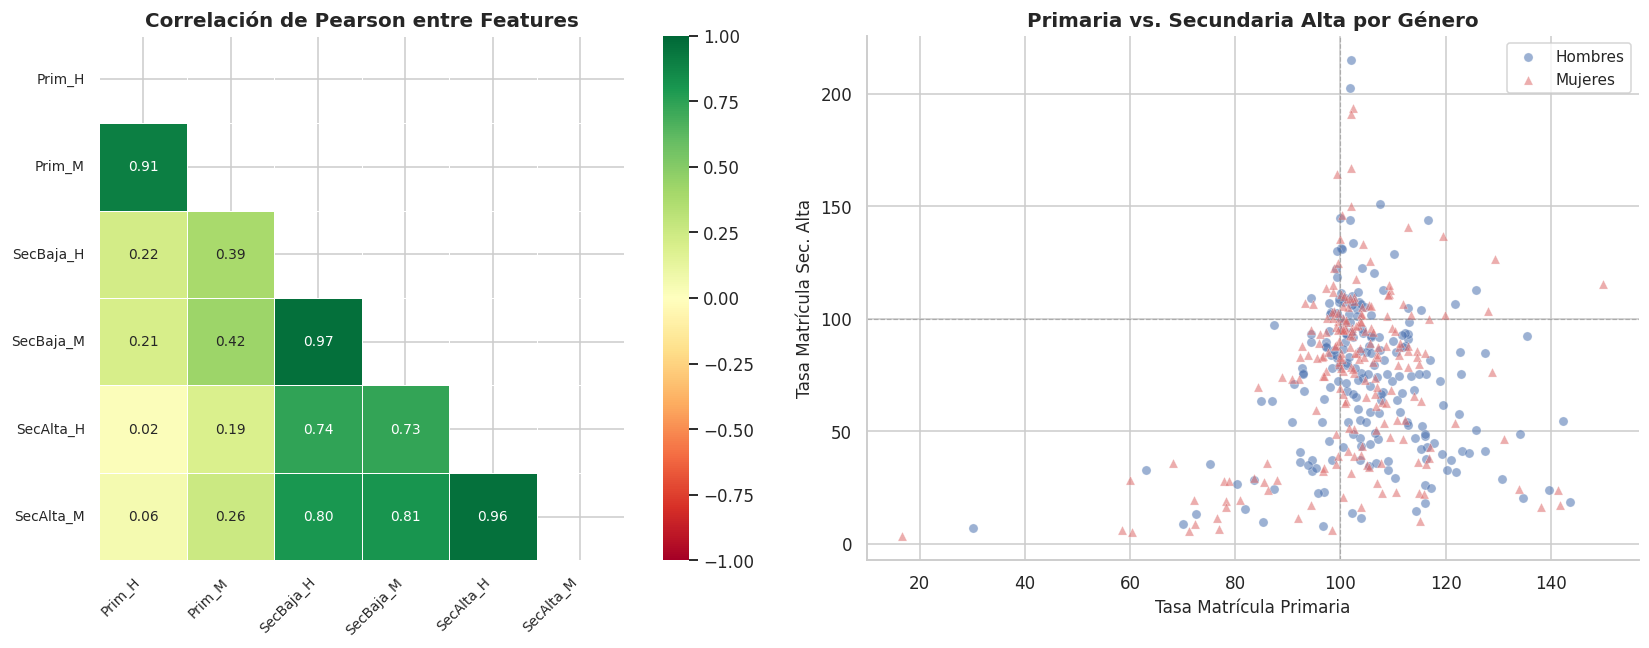

Interpretación:
 • Alta correlación H-M dentro del mismo nivel: países que invierten en primaria lo hacen para ambos géneros.
 • Correlación Primaria-Sec.Alta más débil: algunos países garantizan acceso básico pero no retención.


In [6]:
# ══════════════════════════════════════════════════════════════════
# 4.2 MAPA DE CORRELACIONES
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Heatmap de correlación de Pearson ──
corr = df_pivot[FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, ax=axes[0],
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    linewidths=0.5, square=True
)
axes[0].set_title('Correlación de Pearson entre Features', fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=9)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=9)

# ── Pairplot reducido: primaria vs secundaria alta (por género) ──
df_pair = df_pivot[FEATURES].copy()
axes[1].scatter(df_pair['Prim_H'],    df_pair['SecAlta_H'],
                alpha=0.55, color='#4C72B0', label='Hombres', edgecolors='white', linewidth=0.3)
axes[1].scatter(df_pair['Prim_M'],    df_pair['SecAlta_M'],
                alpha=0.55, color='#DD6B6B', label='Mujeres', marker='^', edgecolors='white', linewidth=0.3)
axes[1].set_xlabel('Tasa Matrícula Primaria', fontsize=11)
axes[1].set_ylabel('Tasa Matrícula Sec. Alta', fontsize=11)
axes[1].set_title('Primaria vs. Secundaria Alta por Género', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].axvline(100, color='gray', lw=0.8, ls='--', alpha=0.5)
axes[1].axhline(100, color='gray', lw=0.8, ls='--', alpha=0.5)

plt.tight_layout()
plt.savefig('eda_correlaciones.png', bbox_inches='tight', dpi=120)
plt.show()

print("Interpretación:")
print(" • Alta correlación H-M dentro del mismo nivel: países que invierten en primaria lo hacen para ambos géneros.")
print(" • Correlación Primaria-Sec.Alta más débil: algunos países garantizan acceso básico pero no retención.")


### 4.3 Distribuciones y detección de outliers


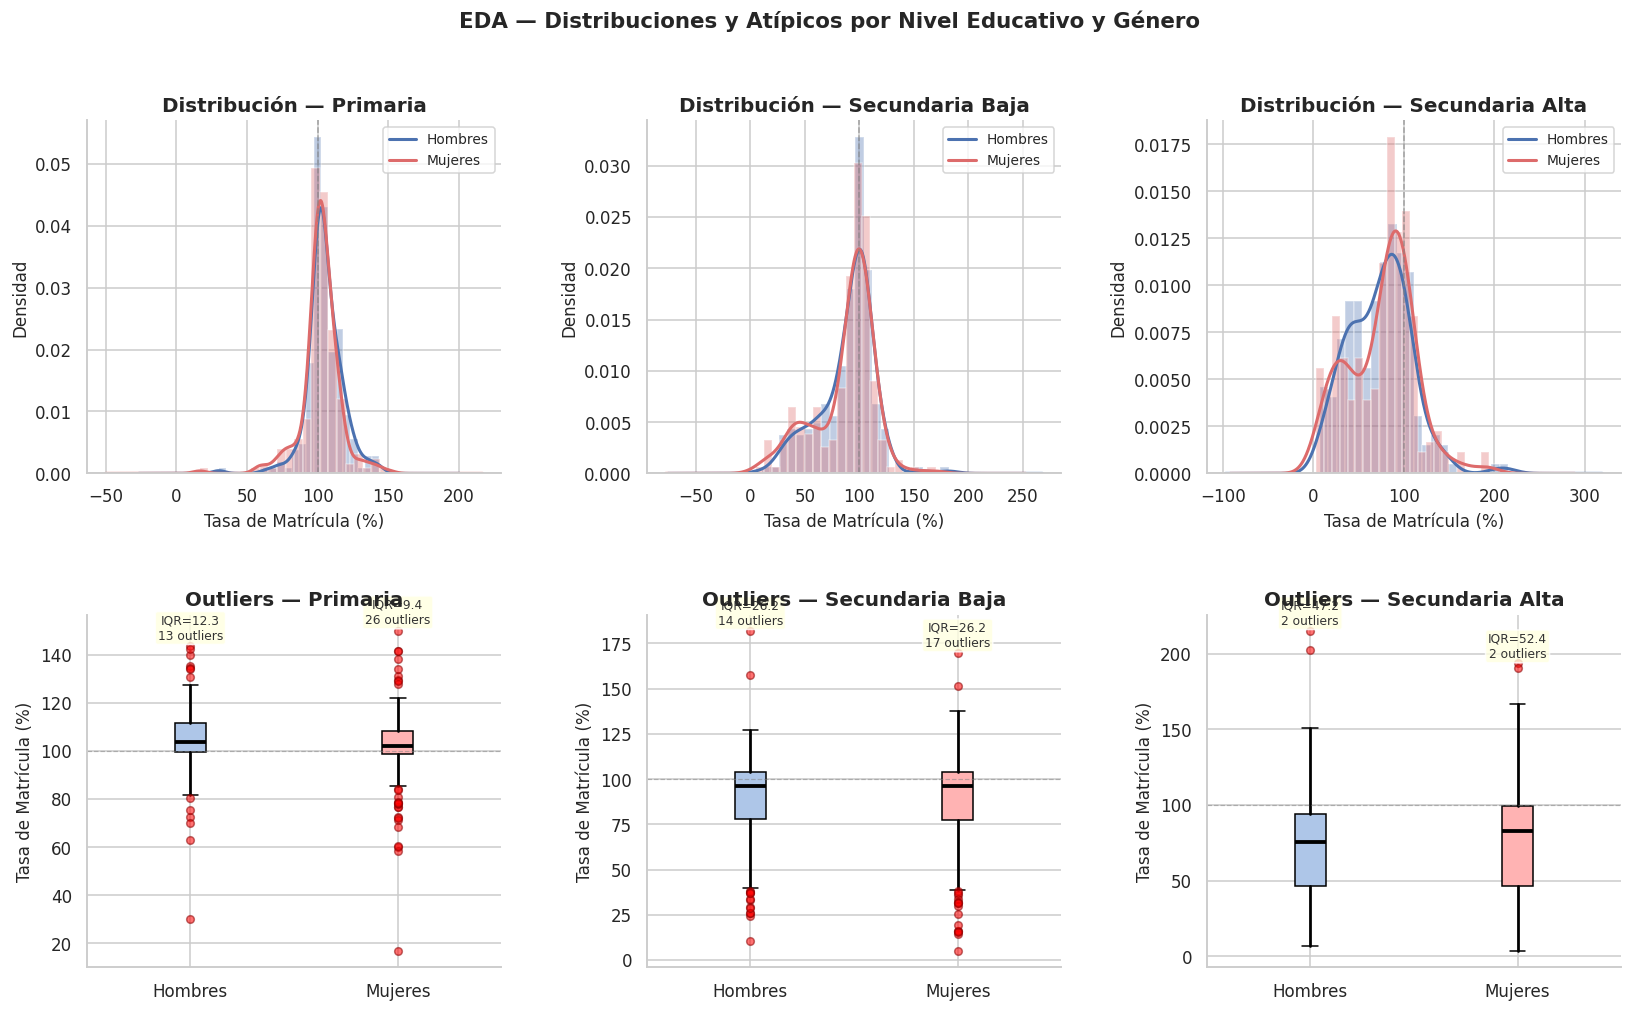


── RESUMEN CUANTITATIVO DE OUTLIERS (Método IQR) ──
Feature            N  Outliers   % Outliers
--------------------------------------------
Prim_H           207        13         6.3%
Prim_M           207        26        12.6%
SecBaja_H        207        14         6.8%
SecBaja_M        207        17         8.2%
SecAlta_H        207         2         1.0%
SecAlta_M        207         2         1.0%


In [7]:
# ══════════════════════════════════════════════════════════════════
# 4.3 DISTRIBUCIONES POR NIVEL Y BOXPLOTS
# ══════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

niveles = [
    ('Prim_H',    'Prim_M',    'Primaria'),
    ('SecBaja_H', 'SecBaja_M', 'Secundaria Baja'),
    ('SecAlta_H', 'SecAlta_M', 'Secundaria Alta'),
]

colores = {'Hombres': '#4C72B0', 'Mujeres': '#DD6B6B'}

for j, (col_h, col_m, label) in enumerate(niveles):
    # ── Fila 1: KDE + histograma ──
    ax1 = fig.add_subplot(gs[0, j])
    for col, genero, color in [(col_h,'Hombres','#4C72B0'),(col_m,'Mujeres','#DD6B6B')]:
        ax1.hist(df_pivot[col].dropna(), bins=22, alpha=0.35, color=color, density=True)
        df_pivot[col].dropna().plot.kde(ax=ax1, color=color, lw=2, label=genero)
    ax1.axvline(100, color='gray', lw=1, ls='--', alpha=0.6)
    ax1.set_title(f'Distribución — {label}', fontweight='bold')
    ax1.set_xlabel('Tasa de Matrícula (%)')
    ax1.set_ylabel('Densidad')
    ax1.legend(fontsize=9)

    # ── Fila 2: Boxplot con outliers IQR ──
    ax2 = fig.add_subplot(gs[1, j])
    datos = [df_pivot[col_h].dropna(), df_pivot[col_m].dropna()]
    bp = ax2.boxplot(
        datos, patch_artist=True, notch=False,
        medianprops=dict(color='black', linewidth=2.5),
        whiskerprops=dict(linewidth=1.8),
        flierprops=dict(marker='o', markerfacecolor='red',
                       markersize=5, alpha=0.55, markeredgecolor='darkred')
    )
    bp['boxes'][0].set_facecolor('#AEC6E8')
    bp['boxes'][1].set_facecolor('#FFB3B3')
    ax2.set_xticklabels(['Hombres', 'Mujeres'], fontsize=11)
    ax2.set_title(f'Outliers — {label}', fontweight='bold')
    ax2.set_ylabel('Tasa de Matrícula (%)')
    ax2.axhline(100, color='gray', lw=0.8, ls='--', alpha=0.5)

    # Anotar IQR y número de outliers
    for k, datos_gen in enumerate(datos):
        q1_, q3_ = datos_gen.quantile(0.25), datos_gen.quantile(0.75)
        iqr_ = q3_ - q1_
        n_out = ((datos_gen < q1_ - 1.5*iqr_) | (datos_gen > q3_ + 1.5*iqr_)).sum()
        ax2.text(k+1, datos_gen.max()*1.02, f'IQR={iqr_:.1f}\n{n_out} outliers',
                ha='center', fontsize=8, color='#333333',
                bbox=dict(boxstyle='round,pad=0.2', fc='lightyellow', alpha=0.8))

fig.suptitle('EDA — Distribuciones y Atípicos por Nivel Educativo y Género',
             fontsize=14, fontweight='bold')
plt.savefig('eda_distribuciones.png', bbox_inches='tight', dpi=120)
plt.show()

# ── Resumen cuantitativo de outliers ──
print("\n── RESUMEN CUANTITATIVO DE OUTLIERS (Método IQR) ──")
print(f"{'Feature':<14} {'N':>5} {'Outliers':>9} {'% Outliers':>12}")
print("-" * 44)
for col in FEATURES:
    s = df_pivot[col].dropna()
    q1_, q3_ = s.quantile(0.25), s.quantile(0.75)
    iqr_ = q3_ - q1_
    n_out = ((s < q1_ - 1.5*iqr_) | (s > q3_ + 1.5*iqr_)).sum()
    print(f"{col:<14} {len(s):>5} {n_out:>9} {n_out/len(s)*100:>11.1f}%")


---
## 5. Modelo 1 — K-Means Clustering

### ¿Qué es K-Means?

K-Means divide los datos en **K grupos** minimizando la suma de distancias cuadradas de cada punto a su centroide.  
Requiere especificar K a priori y asume clusters de **forma esférica** y **tamaño similar**.

**Proceso iterativo:**
1. Inicializar K centroides aleatoriamente (se usa `k-means++` para mejor inicialización)
2. Asignar cada punto al centroide más cercano
3. Recalcular centroides como media del cluster
4. Repetir hasta convergencia

### 5.1 Selección del número óptimo de clusters — Método del Codo + Silhouette


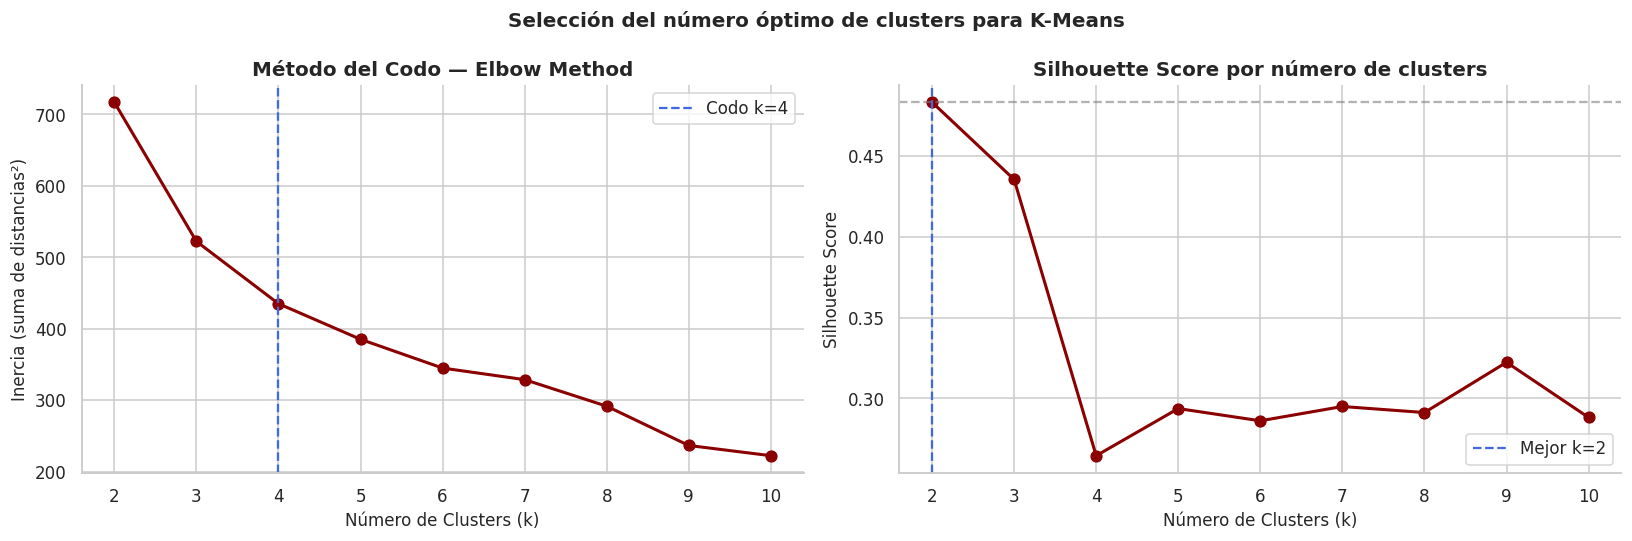

Resumen de métricas por k:
   k      Inercia   Silhouette
------------------------------
   2        717.1       0.4833 ← ÓPTIMO
   3        522.3       0.4355
   4        435.1       0.2645
   5        385.2       0.2937
   6        344.9       0.2861
   7        328.7       0.2950
   8        291.5       0.2912
   9        236.5       0.3223
  10        222.2       0.2882


In [8]:
# ══════════════════════════════════════════════════════════════════
# 5.1 NÚMERO ÓPTIMO DE CLUSTERS — ELBOW + SILHOUETTE
# ══════════════════════════════════════════════════════════════════

k_range = range(2, 11)
inercias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Método del Codo ──
axes[0].plot(k_range, inercias, 'o-', color='#8B0000', linewidth=2, markersize=7)
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Inercia (suma de distancias²)')
axes[0].set_title('Método del Codo — Elbow Method', fontweight='bold')
axes[0].set_xticks(list(k_range))

# Resaltar el codo visualmente
best_k_elbow = 4  # se ajustará visualmente
axes[0].axvline(best_k_elbow, color='royalblue', ls='--', lw=1.5, label=f'Codo k={best_k_elbow}')
axes[0].legend()

# ── Silhouette Score ──
best_sil_idx = int(np.argmax(silhouettes))
best_k_sil   = list(k_range)[best_sil_idx]

axes[1].plot(k_range, silhouettes, 'o-', color='darkred', linewidth=2, markersize=7)
axes[1].axhline(y=max(silhouettes), color='gray', ls='--', alpha=0.6)
axes[1].axvline(best_k_sil, color='royalblue', ls='--', lw=1.5, label=f'Mejor k={best_k_sil}')
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por número de clusters', fontweight='bold')
axes[1].set_xticks(list(k_range))
axes[1].legend()

plt.suptitle('Selección del número óptimo de clusters para K-Means',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_seleccion_k.png', bbox_inches='tight', dpi=120)
plt.show()

print("Resumen de métricas por k:")
print(f"{'k':>4} {'Inercia':>12} {'Silhouette':>12}")
print("-" * 30)
for k, in_, sil in zip(k_range, inercias, silhouettes):
    marca = " ← ÓPTIMO" if k == best_k_sil else ""
    print(f"{k:>4} {in_:>12.1f} {sil:>12.4f}{marca}")


### 5.2 Ajuste del modelo final K-Means


In [9]:
# ══════════════════════════════════════════════════════════════════
# 5.2 MODELO FINAL K-MEANS
# ══════════════════════════════════════════════════════════════════
# Se usa el k determinado por el Silhouette Score máximo.
# Si el codo y el silhouette coinciden, la decisión es robusta.

K_OPTIMO = best_k_sil
print(f"K seleccionado: {K_OPTIMO} (Silhouette Score máximo: {max(silhouettes):.4f})")

kmeans = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init='auto')
df_pivot['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

# Distribución de países por cluster
print("\nDistribución de países por cluster K-Means:")
dist = df_pivot['KMeans_Cluster'].value_counts().sort_index()
for cl, n in dist.items():
    print(f"  Cluster {cl}: {n:>3} países ({n/len(df_pivot)*100:.1f}%)")


K seleccionado: 2 (Silhouette Score máximo: 0.4833)

Distribución de países por cluster K-Means:
  Cluster 0: 154 países (74.4%)
  Cluster 1:  53 países (25.6%)


In [10]:
# ══════════════════════════════════════════════════════════════════
# 5.3 PERFIL MEDIO POR CLUSTER K-MEANS
# ══════════════════════════════════════════════════════════════════

perfil_km = df_pivot.groupby('KMeans_Cluster')[FEATURES].mean().round(1)
perfil_km['N_Paises'] = df_pivot.groupby('KMeans_Cluster')['Pais'].count()

print("="*70)
print("  PERFIL MEDIO POR CLUSTER — K-MEANS")
print("="*70)
print(perfil_km.to_string())
print()

# ── Países más representativos de cada cluster ──
print("Ejemplos de países por cluster:")
for cl in sorted(df_pivot['KMeans_Cluster'].unique()):
    paises_cl = df_pivot[df_pivot['KMeans_Cluster'] == cl]['Pais'].values
    muestra = ', '.join(paises_cl[:6])
    print(f"  Cluster {cl}: {muestra} ...")


  PERFIL MEDIO POR CLUSTER — K-MEANS
                Prim_H  Prim_M  SecBaja_H  SecBaja_M  SecAlta_H  SecAlta_M  N_Paises
KMeans_Cluster                                                                      
0                105.4   104.3      100.7      100.9       87.4       91.9       154
1                103.4    95.7       53.9       47.4       32.6       28.0        53

Ejemplos de países por cluster:
  Cluster 0: "China, Hong Kong SAR", "China, Macao SAR", Albania, Algeria, Anguilla, Antigua and Barbuda ...
  Cluster 1: Afghanistan, Angola, Bangladesh, Benin, Burkina Faso, Burundi ...


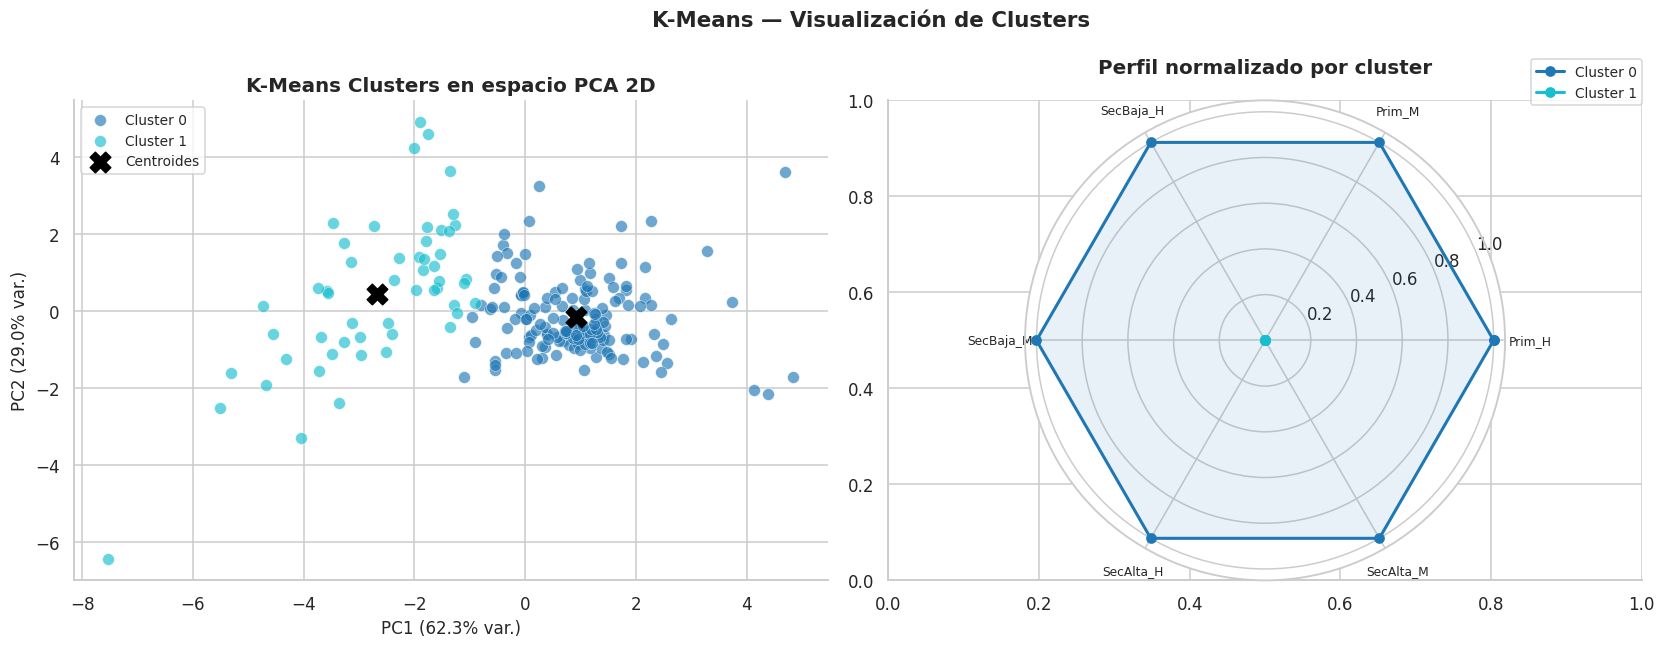

In [11]:
# ══════════════════════════════════════════════════════════════════
# 5.4 VISUALIZACIÓN K-MEANS — PCA 2D + RADAR
# ══════════════════════════════════════════════════════════════════

pca_2d = PCA(n_components=2, random_state=42)
X_pca2 = pca_2d.fit_transform(X_scaled)

paleta = plt.cm.get_cmap('tab10', K_OPTIMO)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Scatter PCA 2D coloreado por K-Means ──
for cl in range(K_OPTIMO):
    mask = df_pivot['KMeans_Cluster'] == cl
    axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    c=[paleta(cl)], label=f'Cluster {cl}',
                    alpha=0.65, edgecolors='white', linewidth=0.4, s=60)

# Marcar centroides en espacio PCA
centroides_pca = pca_2d.transform(kmeans.cluster_centers_)
axes[0].scatter(centroides_pca[:, 0], centroides_pca[:, 1],
                c='black', marker='X', s=180, zorder=5, label='Centroides')

axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var.)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var.)')
axes[0].set_title('K-Means Clusters en espacio PCA 2D', fontweight='bold')
axes[0].legend(fontsize=9)

# ── Radar chart de perfiles por cluster ──
categorias = FEATURES
N = len(categorias)
angulos = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]  # cerrar el polígono

ax_radar = fig.add_subplot(122, polar=True)
perfil_norm = (perfil_km[FEATURES] - perfil_km[FEATURES].min()) / (perfil_km[FEATURES].max() - perfil_km[FEATURES].min())

for cl in range(K_OPTIMO):
    valores = perfil_norm.loc[cl].tolist()
    valores += valores[:1]
    ax_radar.plot(angulos, valores, 'o-', lw=2, color=paleta(cl), label=f'Cluster {cl}')
    ax_radar.fill(angulos, valores, alpha=0.10, color=paleta(cl))

ax_radar.set_xticks(angulos[:-1])
ax_radar.set_xticklabels(categorias, fontsize=8)
ax_radar.set_title('Perfil normalizado por cluster', fontweight='bold', pad=18)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

plt.suptitle('K-Means — Visualización de Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_clusters.png', bbox_inches='tight', dpi=120)
plt.show()


---
## 6. Modelo 2 — DBSCAN Clustering

### ¿Qué es DBSCAN?

DBSCAN (*Density-Based Spatial Clustering of Applications with Noise*) agrupa puntos en zonas **densas**,  
sin necesitar especificar K a priori. Sus dos parámetros clave son:

- **`eps` (ε):** radio máximo para que dos puntos sean "vecinos"  
- **`min_samples`:** número mínimo de vecinos para que un punto sea *core point*

Los puntos que no pertenecen a ninguna región densa se etiquetan como **ruido (`-1`)**, lo cual es  
precisamente su ventaja frente a K-Means: detecta países con perfiles verdaderamente atípicos.

### 6.1 Selección de parámetros — K-Distance Graph


min_samples usado para el gráfico k-distance: 7


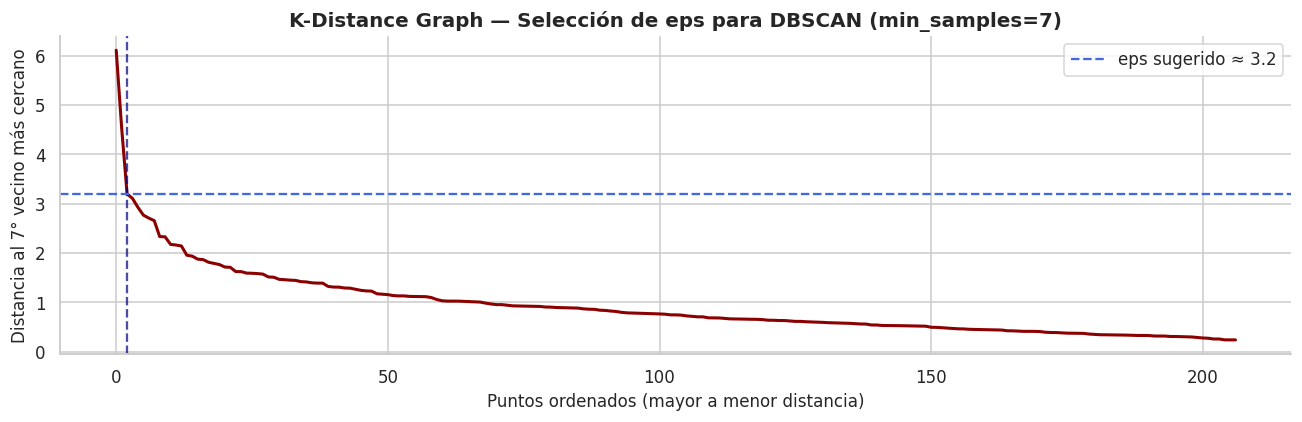


Valor de eps sugerido por el codo: 3.2
Se probarán variaciones alrededor de este valor.


In [12]:
# ══════════════════════════════════════════════════════════════════
# 6.1 K-DISTANCE GRAPH — Elección de eps
# ══════════════════════════════════════════════════════════════════
# Regla práctica: min_samples = dimensiones + 1 = 7.
# El codo de la curva k-distance sugiere un buen valor de eps.

MIN_SAMPLES = max(5, X_scaled.shape[1] + 1)
print(f"min_samples usado para el gráfico k-distance: {MIN_SAMPLES}")

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled)
distancias, _ = nbrs.kneighbors(X_scaled)

kth_dist = np.sort(distancias[:, MIN_SAMPLES - 1])[::-1]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(kth_dist, color='#8B0000', lw=2)
ax.set_xlabel('Puntos ordenados (mayor a menor distancia)')
ax.set_ylabel(f'Distancia al {MIN_SAMPLES}° vecino más cercano')
ax.set_title(f'K-Distance Graph — Selección de eps para DBSCAN (min_samples={MIN_SAMPLES})',
             fontweight='bold')

# Identificar codo automáticamente
diffs  = np.diff(kth_dist)
codo   = int(np.argmax(np.abs(np.diff(diffs)))) + 1
eps_sugerido = round(kth_dist[codo], 2)

ax.axvline(codo, color='navy', lw=1.5, ls='--', alpha=0.7)
ax.axhline(eps_sugerido, color='royalblue', lw=1.5, ls='--',
           label=f'eps sugerido ≈ {eps_sugerido}')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('dbscan_kdistance.png', bbox_inches='tight', dpi=120)
plt.show()

print(f"\nValor de eps sugerido por el codo: {eps_sugerido}")
print("Se probarán variaciones alrededor de este valor.")


### 6.2 Búsqueda de parámetros óptimos


In [13]:
# ══════════════════════════════════════════════════════════════════
# 6.2 GRID SEARCH DE PARÁMETROS DBSCAN
# ══════════════════════════════════════════════════════════════════

eps_valores     = np.arange(0.3, 2.1, 0.1).round(1)
ms_valores      = [3, 5, 7, 10]
resultados_db   = []

for eps_ in eps_valores:
    for ms_ in ms_valores:
        db    = DBSCAN(eps=eps_, min_samples=ms_)
        labels = db.fit_predict(X_scaled)
        n_cls  = len(set(labels)) - (1 if -1 in labels else 0)
        n_ruid = (labels == -1).sum()
        mask_ok = labels != -1
        if n_cls > 1 and mask_ok.sum() > 10:
            sil = silhouette_score(X_scaled[mask_ok], labels[mask_ok])
        else:
            sil = np.nan
        resultados_db.append({'eps': eps_, 'min_samples': ms_,
                              'n_clusters': n_cls, 'n_ruido': n_ruid, 'silhouette': sil})

df_grid = pd.DataFrame(resultados_db)

# Filtrar configuraciones razonables (2-8 clusters, <40% ruido)
df_grid_ok = df_grid[
    (df_grid['n_clusters'].between(2, 8)) &
    (df_grid['n_ruido'] < len(df_pivot) * 0.40)
].dropna(subset=['silhouette'])

print("Top 10 configuraciones DBSCAN (clusters razonables, < 40% ruido):")
print(df_grid_ok.sort_values('silhouette', ascending=False).head(10).to_string(index=False))

# Seleccionar la mejor configuración
if len(df_grid_ok) > 0:
    mejor = df_grid_ok.loc[df_grid_ok['silhouette'].idxmax()]
    EPS_OPT = mejor['eps']
    MS_OPT  = int(mejor['min_samples'])
else:
    EPS_OPT = eps_sugerido
    MS_OPT  = MIN_SAMPLES

print(f"\n→ Configuración seleccionada: eps={EPS_OPT}, min_samples={MS_OPT}")


Top 10 configuraciones DBSCAN (clusters razonables, < 40% ruido):
 eps  min_samples  n_clusters  n_ruido  silhouette
 1.1            5           2       31    0.532800
 1.0            5           2       37    0.528396
 1.3            7           2       20    0.505437
 1.4            7           2       18    0.501630
 1.3            5           2       19    0.497845
 0.9           10           2       58    0.495247
 1.4            5           2       17    0.494145
 1.1            3           3       17    0.493344
 1.2            7           2       24    0.491821
 1.2            5           2       20    0.487646

→ Configuración seleccionada: eps=1.1, min_samples=5


In [14]:
# ══════════════════════════════════════════════════════════════════
# 6.3 MODELO FINAL DBSCAN
# ══════════════════════════════════════════════════════════════════

dbscan = DBSCAN(eps=EPS_OPT, min_samples=MS_OPT)
df_pivot['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(df_pivot['DBSCAN_Cluster'])) - 1  # excluir ruido (-1)
n_ruido_db    = (df_pivot['DBSCAN_Cluster'] == -1).sum()

print(f"{'='*55}")
print(f"  RESULTADOS DBSCAN (eps={EPS_OPT}, min_samples={MS_OPT})")
print(f"{'='*55}")
print(f"  Clusters encontrados : {n_clusters_db}")
print(f"  Países en clusters   : {len(df_pivot) - n_ruido_db} ({(1 - n_ruido_db/len(df_pivot))*100:.1f}%)")
print(f"  Países como ruido    : {n_ruido_db} ({n_ruido_db/len(df_pivot)*100:.1f}%)")
print(f"{'='*55}")

print("\nPaíses identificados como ruido (outliers genuinos):")
print(df_pivot[df_pivot['DBSCAN_Cluster'] == -1]['Pais'].values)


  RESULTADOS DBSCAN (eps=1.1, min_samples=5)
  Clusters encontrados : 2
  Países en clusters   : 176 (85.0%)
  Países como ruido    : 31 (15.0%)

Países identificados como ruido (outliers genuinos):
<StringArray>
[              'Afghanistan',                 'Australia',
 'Australia and New Zealand',                   'Belgium',
                   'Burundi',  'Central African Republic',
                   'Curaçao',             'Côte dIvoire',
                  'Djibouti',         'Equatorial Guinea',
                   'Eritrea',                    'Gambia',
             'Guinea-Bissau',                  'Honduras',
                'Madagascar',                    'Malawi',
                'Mauritania',                    'Monaco',
                'Montserrat',                'Mozambique',
                     'Niger',          'Papua New Guinea',
                    'Rwanda',              'Sierra Leone',
 'Sint Maarten (Dutch part)',                   'Somalia',
               'Sout

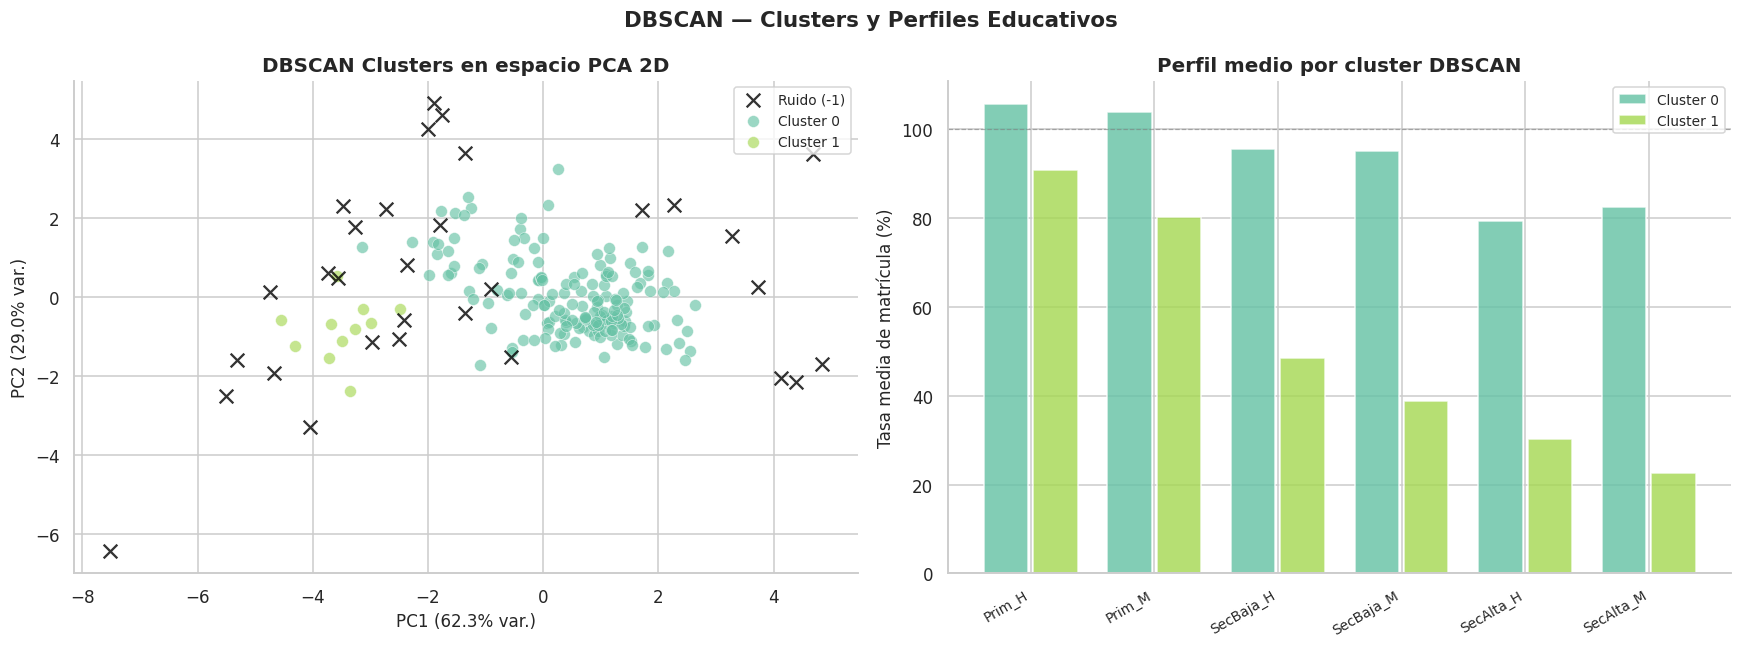


Perfil medio por cluster DBSCAN (sin ruido):
                Prim_H  Prim_M  SecBaja_H  SecBaja_M  SecAlta_H  SecAlta_M  N_Paises
DBSCAN_Cluster                                                                      
0                105.7   103.8       95.5       95.1       79.4       82.6       165
1                 90.8    80.2       48.6       38.7       30.2       22.7        11


In [15]:
# ══════════════════════════════════════════════════════════════════
# 6.4 PERFIL MEDIO Y VISUALIZACIÓN DBSCAN
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
paleta_db = plt.cm.get_cmap('Set2', n_clusters_db + 1)

# ── Scatter PCA 2D coloreado por DBSCAN ──
for cl in sorted(df_pivot['DBSCAN_Cluster'].unique()):
    mask = df_pivot['DBSCAN_Cluster'] == cl
    if cl == -1:
        axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                        c='black', marker='x', s=80, alpha=0.8, label='Ruido (-1)', zorder=5)
    else:
        axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                        c=[paleta_db(cl)], label=f'Cluster {cl}',
                        alpha=0.65, edgecolors='white', linewidth=0.4, s=60)

axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var.)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var.)')
axes[0].set_title('DBSCAN Clusters en espacio PCA 2D', fontweight='bold')
axes[0].legend(fontsize=9)

# ── Perfil medio de clusters DBSCAN (excluye ruido) ──
df_no_ruido = df_pivot[df_pivot['DBSCAN_Cluster'] != -1]
perfil_db   = df_no_ruido.groupby('DBSCAN_Cluster')[FEATURES].mean().round(1)

x_pos = np.arange(len(FEATURES))
bar_w = 0.8 / max(1, n_clusters_db)

for i, cl in enumerate(perfil_db.index):
    axes[1].bar(x_pos + i * bar_w, perfil_db.loc[cl], bar_w * 0.9,
                label=f'Cluster {cl}', color=paleta_db(cl), alpha=0.82)

axes[1].set_xticks(x_pos + bar_w * (n_clusters_db - 1) / 2)
axes[1].set_xticklabels(FEATURES, rotation=30, ha='right', fontsize=9)
axes[1].axhline(100, color='gray', lw=0.8, ls='--', alpha=0.6)
axes[1].set_ylabel('Tasa media de matrícula (%)')
axes[1].set_title('Perfil medio por cluster DBSCAN', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('DBSCAN — Clusters y Perfiles Educativos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dbscan_clusters.png', bbox_inches='tight', dpi=120)
plt.show()

print("\nPerfil medio por cluster DBSCAN (sin ruido):")
perfil_db['N_Paises'] = df_no_ruido.groupby('DBSCAN_Cluster')['Pais'].count()
print(perfil_db.to_string())


---
## 7. Modelo 3 — PCA (Análisis de Componentes Principales)

### ¿Qué es PCA?

PCA es una técnica de **reducción de dimensionalidad lineal** que transforma las variables originales  
en **componentes principales** (PC), combinaciones lineales ortogonales que maximizan la varianza explicada.

**En este análisis PCA cumple dos roles:**
1. **Herramienta de análisis:** revela qué dimensiones latentes estructuran los sistemas educativos globales
2. **Herramienta de visualización:** proyecta los 6 features a 2D para graficar los clusters

### 7.1 Varianza explicada por componente


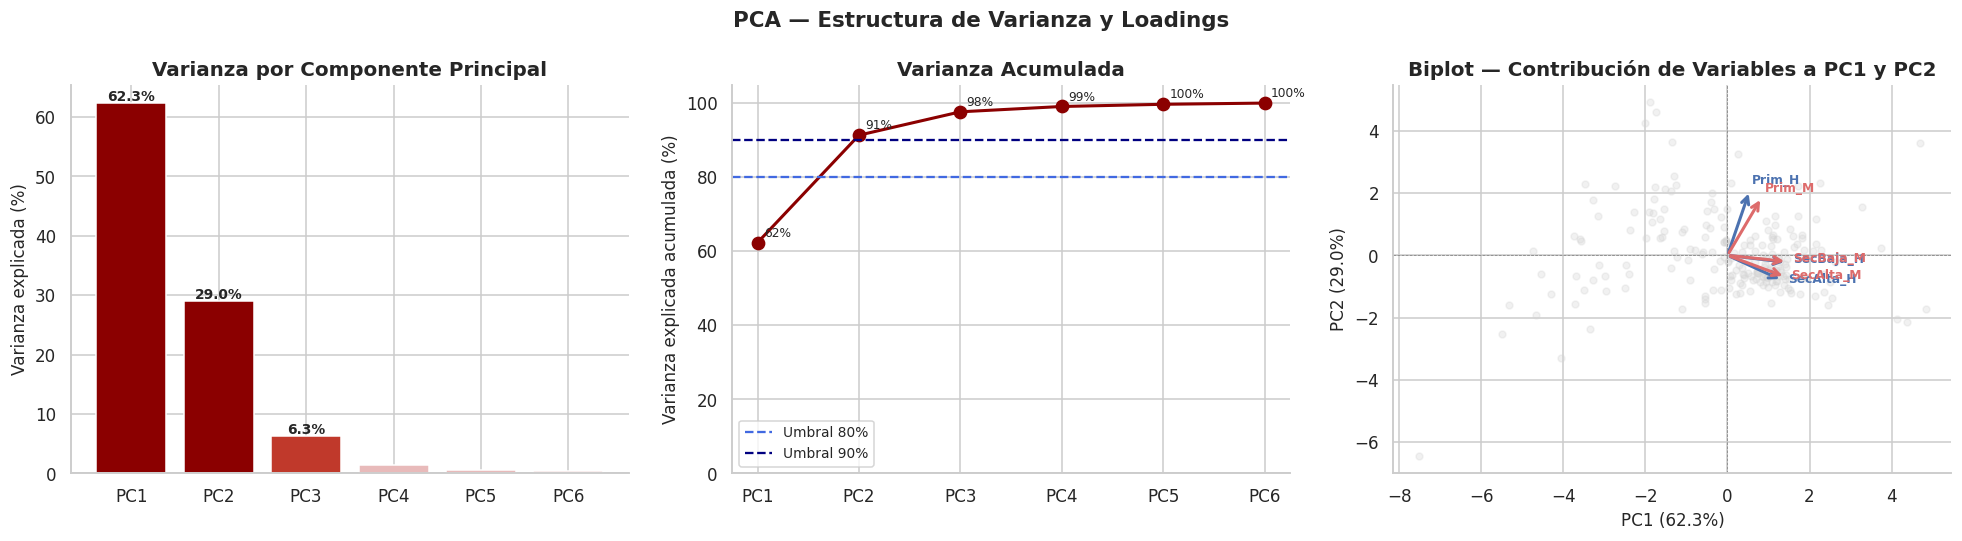

Varianza explicada por PC1+PC2: 91.3%
Componentes necesarios para ≥80% de varianza: 2
Componentes necesarios para ≥90% de varianza: 2

Loadings (PC1 y PC2):
             PC1    PC2
Prim_H     0.180  0.693
Prim_M     0.278  0.620
SecBaja_H  0.484 -0.076
SecBaja_M  0.486 -0.067
SecAlta_H  0.445 -0.268
SecAlta_M  0.471 -0.231


In [16]:
# ══════════════════════════════════════════════════════════════════
# 7.1 PCA COMPLETO — VARIANZA EXPLICADA
# ══════════════════════════════════════════════════════════════════

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

var_ratio  = pca_full.explained_variance_ratio_
var_cumsum = np.cumsum(var_ratio)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Varianza por componente (barras) ──
componentes = [f'PC{i+1}' for i in range(len(var_ratio))]
bars = axes[0].bar(componentes, var_ratio * 100,
                   color=['#8B0000' if v > 0.10 else '#C0392B' if v > 0.05 else '#E8BABA'
                          for v in var_ratio])
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Varianza por Componente Principal', fontweight='bold')
for bar, v in zip(bars, var_ratio):
    if v > 0.03:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{v*100:.1f}%', ha='center', fontsize=9, fontweight='bold')

# ── Varianza acumulada ──
axes[1].plot(componentes, var_cumsum * 100, 'o-', color='darkred', lw=2, markersize=8)
axes[1].axhline(80, color='royalblue', ls='--', lw=1.5, label='Umbral 80%')
axes[1].axhline(90, color='navy',      ls='--', lw=1.5, label='Umbral 90%')
for i, (c, v) in enumerate(zip(componentes, var_cumsum)):
    axes[1].annotate(f'{v*100:.0f}%', (c, v*100),
                    textcoords='offset points', xytext=(4, 4), fontsize=8)
axes[1].set_ylabel('Varianza explicada acumulada (%)')
axes[1].set_title('Varianza Acumulada', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 105)

# ── Loadings (biplot simplificado) ──
pca2 = PCA(n_components=2, random_state=42)
X_pca2_full = pca2.fit_transform(X_scaled)
loadings_df = pd.DataFrame(pca2.components_.T, index=FEATURES, columns=['PC1', 'PC2'])

colors_feat = ['#4C72B0' if 'H' in f else '#DD6B6B' for f in FEATURES]
sc = axes[2].scatter(X_pca2_full[:, 0], X_pca2_full[:, 1], alpha=0.3, s=20, color='lightgray')

scale = 3.0
for i, feat in enumerate(FEATURES):
    axes[2].annotate('', xy=(loadings_df.loc[feat,'PC1']*scale,
                              loadings_df.loc[feat,'PC2']*scale),
                    xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=colors_feat[i], lw=2))
    axes[2].text(loadings_df.loc[feat,'PC1']*scale*1.1,
                 loadings_df.loc[feat,'PC2']*scale*1.1,
                 feat, fontsize=8, color=colors_feat[i], fontweight='bold')

axes[2].axhline(0, color='gray', lw=0.5, ls='--')
axes[2].axvline(0, color='gray', lw=0.5, ls='--')
axes[2].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
axes[2].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
axes[2].set_title('Biplot — Contribución de Variables a PC1 y PC2', fontweight='bold')

plt.suptitle('PCA — Estructura de Varianza y Loadings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_varianza.png', bbox_inches='tight', dpi=120)
plt.show()

print(f"Varianza explicada por PC1+PC2: {var_cumsum[1]*100:.1f}%")
print(f"Componentes necesarios para ≥80% de varianza: {(var_cumsum >= 0.80).argmax() + 1}")
print(f"Componentes necesarios para ≥90% de varianza: {(var_cumsum >= 0.90).argmax() + 1}")
print("\nLoadings (PC1 y PC2):")
print(loadings_df.round(3).to_string())


### 7.2 Interpretación de los componentes principales


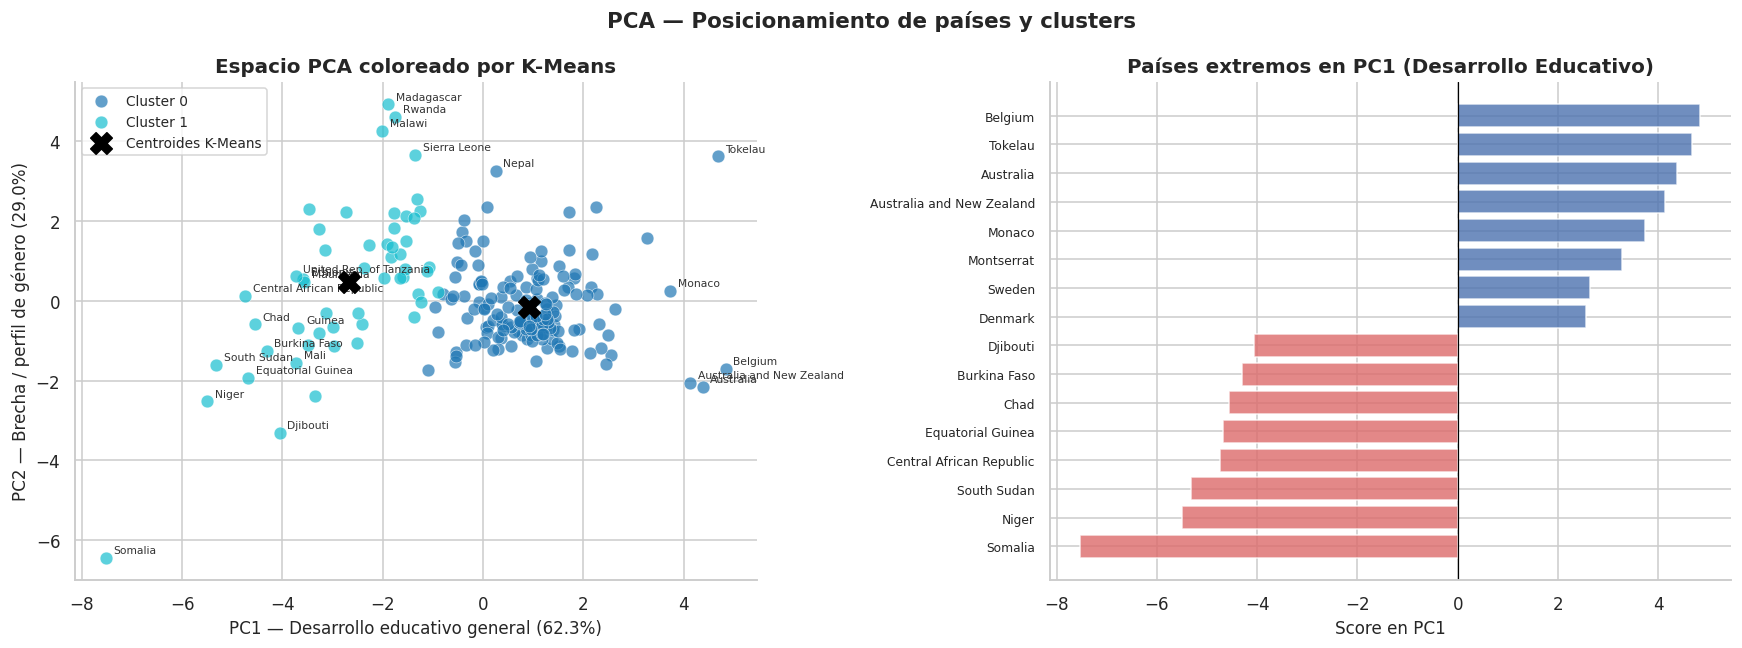

In [17]:
# ══════════════════════════════════════════════════════════════════
# 7.2 PCA — VISUALIZACIÓN CON CLUSTERS K-MEANS
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
paleta = plt.cm.get_cmap('tab10', K_OPTIMO)

for cl in range(K_OPTIMO):
    mask = df_pivot['KMeans_Cluster'] == cl
    axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    c=[paleta(cl)], label=f'Cluster {cl}',
                    alpha=0.7, edgecolors='white', linewidth=0.4, s=70)

axes[0].scatter(centroides_pca[:, 0], centroides_pca[:, 1],
                c='black', marker='X', s=200, zorder=6, label='Centroides K-Means')
axes[0].set_xlabel(f'PC1 — Desarrollo educativo general ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 — Brecha / perfil de género ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('Espacio PCA coloreado por K-Means', fontweight='bold')
axes[0].legend(fontsize=9)

# Anotar algunos países extremos en PC1 y PC2
for idx, (pc1, pc2, pais) in enumerate(zip(X_pca2[:, 0], X_pca2[:, 1], paises)):
    if abs(pc1) > 3.5 or abs(pc2) > 3.0:
        axes[0].annotate(pais, (pc1, pc2), fontsize=7,
                        xytext=(5, 3), textcoords='offset points', color='#333333')

# ── Mapa de calor: score PC1 vs feature ──
scores_pc1 = pd.Series(X_pca2[:, 0], index=paises).sort_values()
top_bottom = pd.concat([scores_pc1.head(8), scores_pc1.tail(8)])
colors_bar = ['#DD6B6B' if v < 0 else '#4C72B0' for v in top_bottom.values]

axes[1].barh(range(len(top_bottom)), top_bottom.values, color=colors_bar, alpha=0.8)
axes[1].set_yticks(range(len(top_bottom)))
axes[1].set_yticklabels(top_bottom.index, fontsize=8)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Países extremos en PC1 (Desarrollo Educativo)', fontweight='bold')
axes[1].set_xlabel('Score en PC1')

plt.suptitle('PCA — Posicionamiento de países y clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_clusters.png', bbox_inches='tight', dpi=120)
plt.show()


---
## 8. Modelo 4 — t-SNE (t-Distributed Stochastic Neighbor Embedding)

### ¿Qué es t-SNE?

t-SNE es una técnica de reducción de dimensionalidad **no lineal**, diseñada específicamente para  
**visualización en 2D o 3D**. A diferencia de PCA (que preserva la varianza global), t-SNE preserva  
la **estructura local**: puntos cercanos en el espacio original permanecen cercanos en 2D.

**Parámetros clave:**
- `perplexity`: cuántos vecinos cercanos considera cada punto (~5–50, típicamente 30)
- `learning_rate`: velocidad de ajuste iterativo (200–1000)
- `n_iter`: iteraciones hasta convergencia (≥1000)

> **Advertencia:** t-SNE es estocástico y no reproducible sin `random_state`. No usar para clustering  
> directo — solo para validación visual de clusters obtenidos previamente.

### 8.1 Entrenamiento y comparación de perplejidades


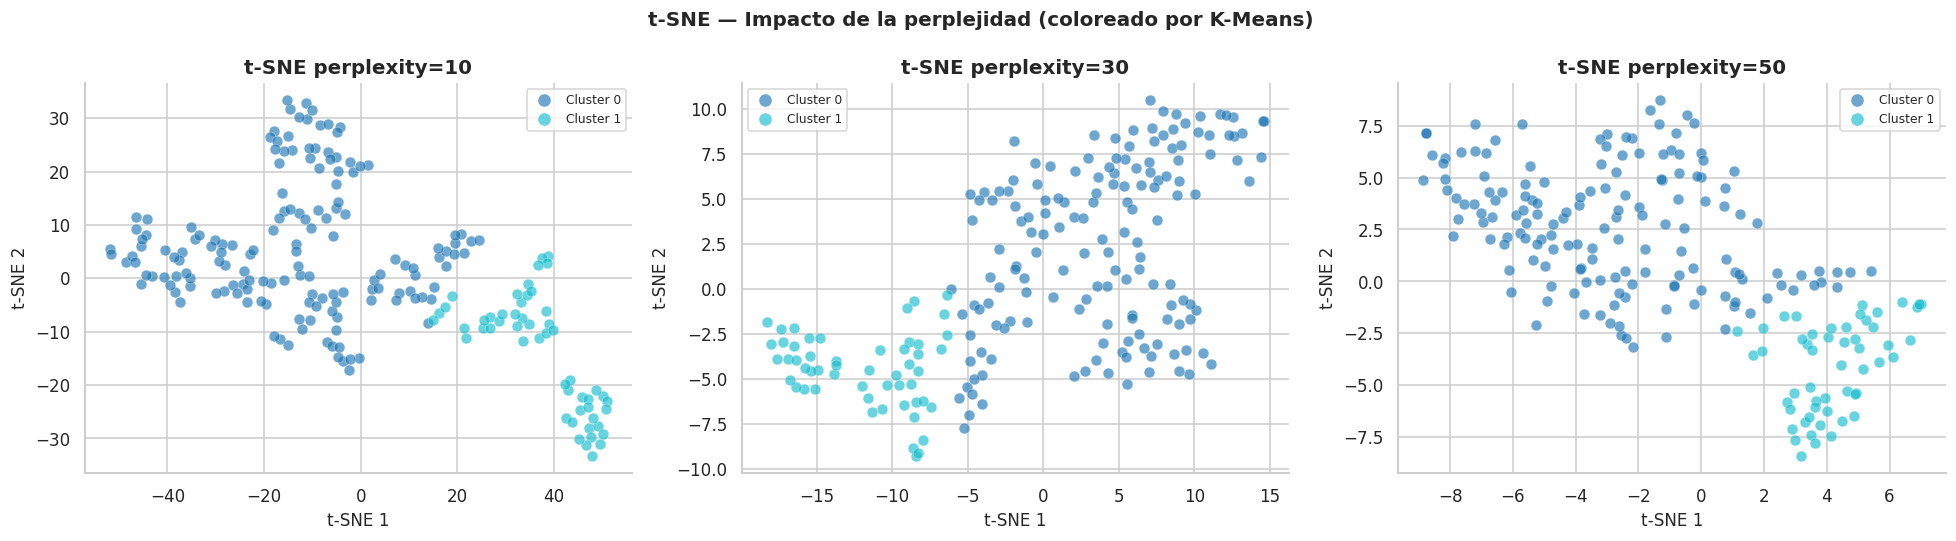

Configuración seleccionada: perplexity=30


In [18]:
# ══════════════════════════════════════════════════════════════════
# 8.1 t-SNE — COMPARACIÓN DE PERPLEJIDADES
# ══════════════════════════════════════════════════════════════════

perplexities = [10, 30, 50]
resultados_tsne = {}

for perp in perplexities:
    tsne_temp = TSNE(n_components=2, perplexity=perp,
                     learning_rate=200, max_iter=1000, random_state=42)
    resultados_tsne[perp] = tsne_temp.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
paleta = plt.cm.get_cmap('tab10', K_OPTIMO)

for ax, perp in zip(axes, perplexities):
    X_t = resultados_tsne[perp]
    for cl in range(K_OPTIMO):
        mask = df_pivot['KMeans_Cluster'] == cl
        ax.scatter(X_t[mask, 0], X_t[mask, 1],
                   c=[paleta(cl)], label=f'Cluster {cl}',
                   alpha=0.65, edgecolors='white', linewidth=0.3, s=50)
    ax.set_title(f't-SNE perplexity={perp}', fontweight='bold')
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.legend(fontsize=8, markerscale=1.2)

plt.suptitle('t-SNE — Impacto de la perplejidad (coloreado por K-Means)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tsne_perplexities.png', bbox_inches='tight', dpi=120)
plt.show()

# Seleccionamos perplexity=30 como configuración estándar
TSNE_PERP = 30
X_tsne = resultados_tsne[TSNE_PERP]
print(f"Configuración seleccionada: perplexity={TSNE_PERP}")


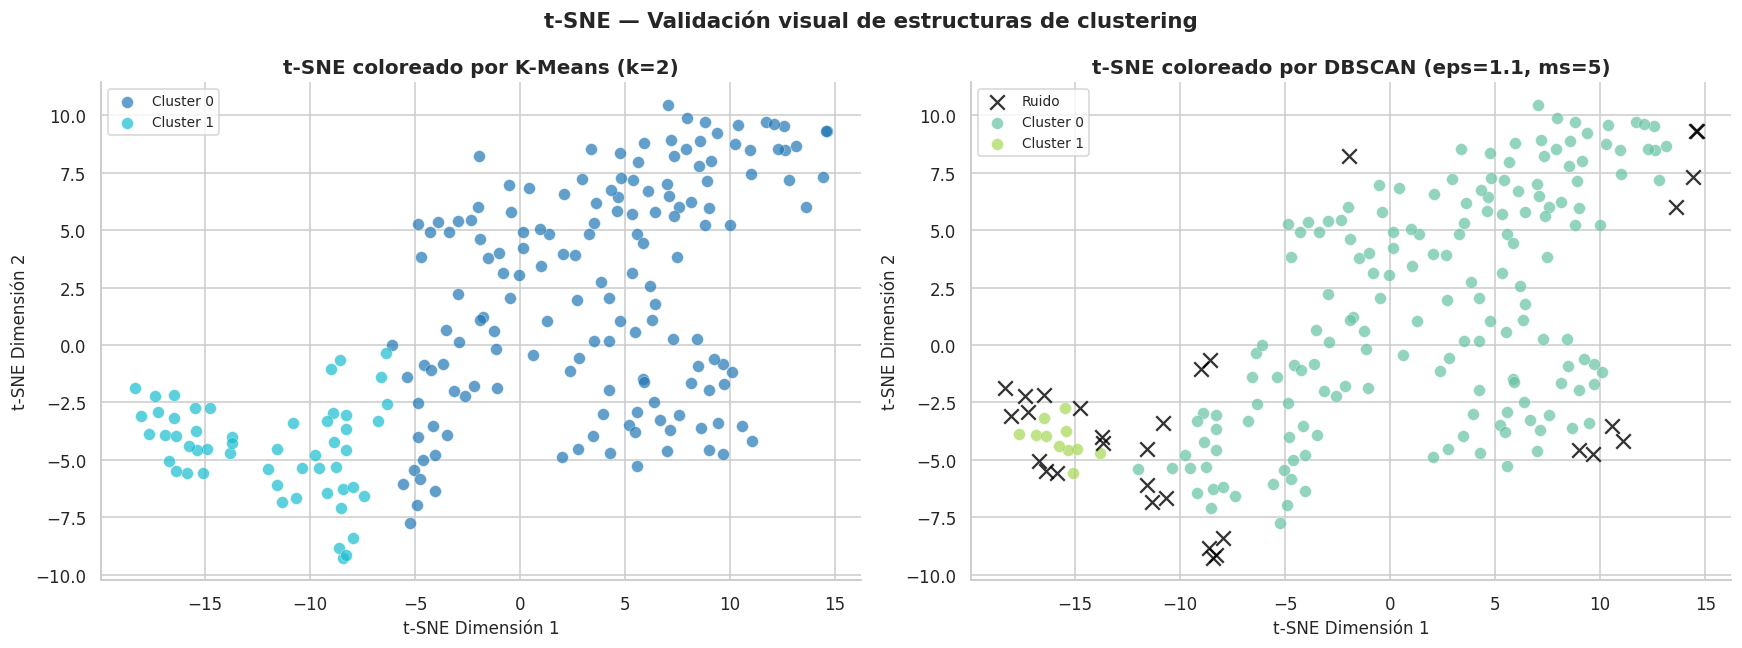

In [19]:
# ══════════════════════════════════════════════════════════════════
# 8.2 t-SNE — K-MEANS vs DBSCAN COMPARADO
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
paleta_km = plt.cm.get_cmap('tab10', K_OPTIMO)
paleta_db = plt.cm.get_cmap('Set2', n_clusters_db + 1)

# ── t-SNE coloreado por K-Means ──
for cl in range(K_OPTIMO):
    mask = df_pivot['KMeans_Cluster'] == cl
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=[paleta_km(cl)], label=f'Cluster {cl}',
                    alpha=0.7, edgecolors='white', linewidth=0.3, s=60)
axes[0].set_title(f't-SNE coloreado por K-Means (k={K_OPTIMO})', fontweight='bold')
axes[0].set_xlabel('t-SNE Dimensión 1'); axes[0].set_ylabel('t-SNE Dimensión 2')
axes[0].legend(fontsize=9)

# ── t-SNE coloreado por DBSCAN ──
for cl in sorted(df_pivot['DBSCAN_Cluster'].unique()):
    mask = df_pivot['DBSCAN_Cluster'] == cl
    if cl == -1:
        axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                        c='black', marker='x', s=90, alpha=0.8, label='Ruido', zorder=5)
    else:
        axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                        c=[paleta_db(cl)], label=f'Cluster {cl}',
                        alpha=0.7, edgecolors='white', linewidth=0.3, s=60)
axes[1].set_title(f't-SNE coloreado por DBSCAN (eps={EPS_OPT}, ms={MS_OPT})', fontweight='bold')
axes[1].set_xlabel('t-SNE Dimensión 1'); axes[1].set_ylabel('t-SNE Dimensión 2')
axes[1].legend(fontsize=9)

plt.suptitle('t-SNE — Validación visual de estructuras de clustering',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tsne_comparacion.png', bbox_inches='tight', dpi=120)
plt.show()


---
## 9. Evaluación Comparativa de Modelos

### Métricas de evaluación para clustering

| Métrica | Rango | Mejor valor | Qué mide |
|---|---|---|---|
| **Silhouette Score** | [-1, 1] | Cercano a 1 | Cohesión interna vs. separación entre clusters |
| **Davies-Bouldin Index** | [0, ∞) | Cercano a 0 | Similaridad promedio entre clusters (menor = mejor) |
| **Calinski-Harabasz Index** | [0, ∞) | Mayor | Ratio varianza inter/intra cluster (mayor = mejor) |


In [20]:
# ══════════════════════════════════════════════════════════════════
# 9.1 TABLA COMPARATIVA DE MÉTRICAS
# ══════════════════════════════════════════════════════════════════

resultados_finales = []

# ── K-Means ──
labels_km = df_pivot['KMeans_Cluster'].values
resultados_finales.append({
    'Modelo'              : f'K-Means (k={K_OPTIMO})',
    'N Clusters'          : K_OPTIMO,
    'N Ruido'             : 0,
    'Silhouette Score'    : round(silhouette_score(X_scaled, labels_km), 4),
    'Davies-Bouldin'      : round(davies_bouldin_score(X_scaled, labels_km), 4),
    'Calinski-Harabasz'   : round(calinski_harabasz_score(X_scaled, labels_km), 2),
})

# ── DBSCAN (sin ruido para métricas) ──
labels_db  = df_pivot['DBSCAN_Cluster'].values
mask_db_ok = labels_db != -1

if (labels_db[mask_db_ok] != labels_db[mask_db_ok][0]).any():  # ≥2 clusters
    resultados_finales.append({
        'Modelo'              : f'DBSCAN (eps={EPS_OPT}, ms={MS_OPT})',
        'N Clusters'          : n_clusters_db,
        'N Ruido'             : n_ruido_db,
        'Silhouette Score'    : round(silhouette_score(X_scaled[mask_db_ok], labels_db[mask_db_ok]), 4),
        'Davies-Bouldin'      : round(davies_bouldin_score(X_scaled[mask_db_ok], labels_db[mask_db_ok]), 4),
        'Calinski-Harabasz'   : round(calinski_harabasz_score(X_scaled[mask_db_ok], labels_db[mask_db_ok]), 2),
    })
else:
    resultados_finales.append({
        'Modelo'              : f'DBSCAN (eps={EPS_OPT}, ms={MS_OPT})',
        'N Clusters'          : n_clusters_db,
        'N Ruido'             : n_ruido_db,
        'Silhouette Score'    : 'N/A (1 cluster)',
        'Davies-Bouldin'      : 'N/A',
        'Calinski-Harabasz'   : 'N/A',
    })

# ── PCA: no produce clusters, se evalúa la varianza explicada ──
resultados_finales.append({
    'Modelo'              : 'PCA (2 componentes)',
    'N Clusters'          : '-',
    'N Ruido'             : '-',
    'Silhouette Score'    : f'{var_cumsum[1]*100:.1f}% var. expl.',
    'Davies-Bouldin'      : '-',
    'Calinski-Harabasz'   : '-',
})

# ── t-SNE: no produce clusters ──
resultados_finales.append({
    'Modelo'              : f't-SNE (perp={TSNE_PERP})',
    'N Clusters'          : '-',
    'N Ruido'             : '-',
    'Silhouette Score'    : 'Visual',
    'Davies-Bouldin'      : '-',
    'Calinski-Harabasz'   : '-',
})

df_resultados = pd.DataFrame(resultados_finales)

print("="*70)
print("  TABLA COMPARATIVA — EVALUACIÓN DE MODELOS NO SUPERVISADOS")
print("="*70)
print(df_resultados.set_index('Modelo').to_string())
print("\nNota: PCA y t-SNE son técnicas de reducción de dimensionalidad,")
print("no algoritmos de clustering. Sus métricas son de diferente naturaleza.")


  TABLA COMPARATIVA — EVALUACIÓN DE MODELOS NO SUPERVISADOS
                       N Clusters N Ruido  Silhouette Score Davies-Bouldin Calinski-Harabasz
Modelo                                                                                      
K-Means (k=2)                   2       0            0.4833         0.9533            150.04
DBSCAN (eps=1.1, ms=5)          2      31            0.5328         0.5764             72.38
PCA (2 componentes)             -       -  91.3% var. expl.              -                 -
t-SNE (perp=30)                 -       -            Visual              -                 -

Nota: PCA y t-SNE son técnicas de reducción de dimensionalidad,
no algoritmos de clustering. Sus métricas son de diferente naturaleza.


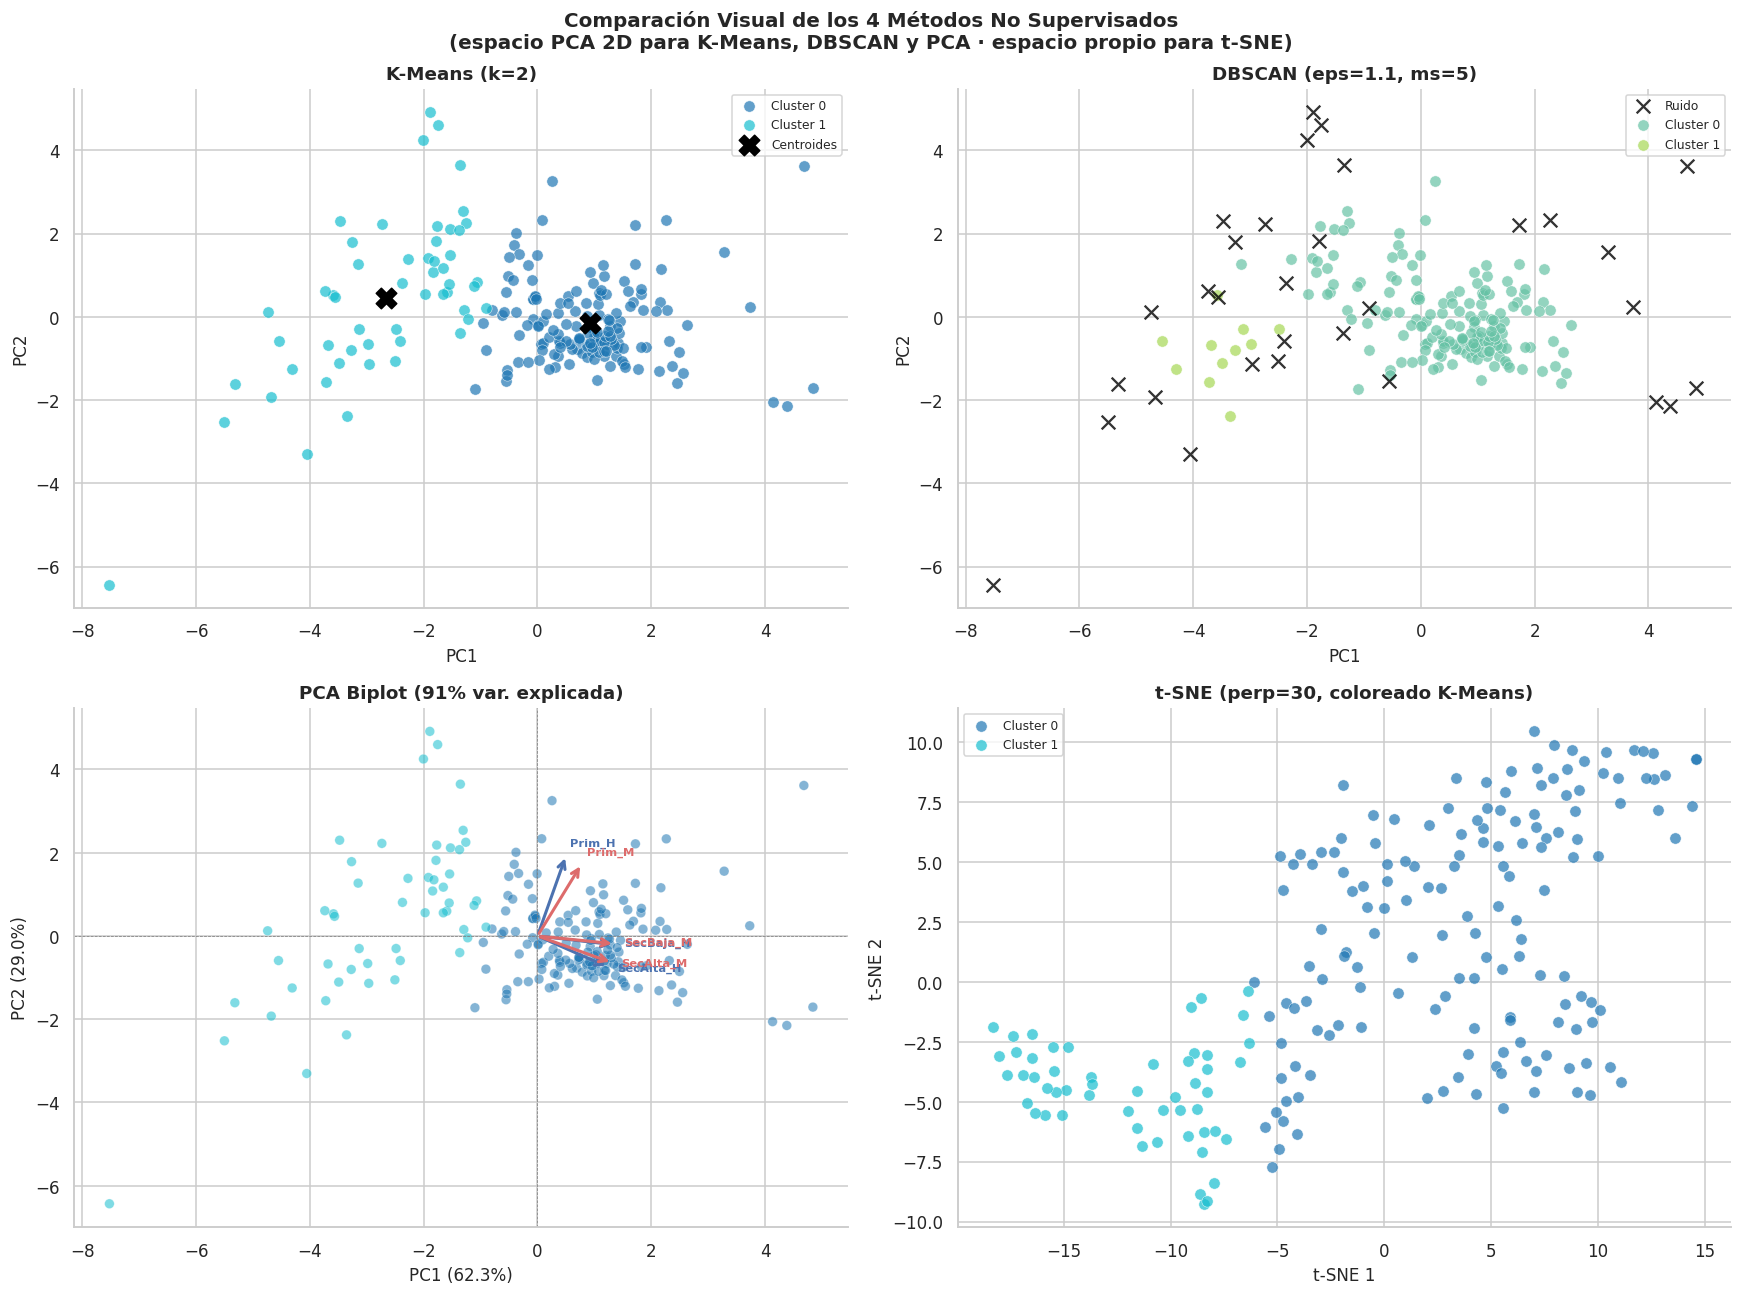

In [21]:
# ══════════════════════════════════════════════════════════════════
# 9.2 VISUALIZACIÓN COMPARATIVA — 4 MODELOS LADO A LADO
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

paleta_km = plt.cm.get_cmap('tab10', K_OPTIMO)
paleta_db = plt.cm.get_cmap('Set2',  n_clusters_db + 1)

# ── Panel 1: K-Means ──
for cl in range(K_OPTIMO):
    mask = df_pivot['KMeans_Cluster'] == cl
    axes[0, 0].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                       c=[paleta_km(cl)], label=f'Cluster {cl}',
                       alpha=0.7, edgecolors='white', lw=0.4, s=55)
axes[0, 0].scatter(centroides_pca[:, 0], centroides_pca[:, 1],
                   c='black', marker='X', s=180, zorder=6, label='Centroides')
axes[0, 0].set_title(f'K-Means (k={K_OPTIMO})', fontweight='bold', fontsize=12)
axes[0, 0].legend(fontsize=8); axes[0, 0].set_xlabel('PC1'); axes[0, 0].set_ylabel('PC2')

# ── Panel 2: DBSCAN ──
for cl in sorted(df_pivot['DBSCAN_Cluster'].unique()):
    mask = df_pivot['DBSCAN_Cluster'] == cl
    if cl == -1:
        axes[0, 1].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                           c='black', marker='x', s=80, alpha=0.8, label='Ruido', zorder=5)
    else:
        axes[0, 1].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                           c=[paleta_db(cl)], label=f'Cluster {cl}',
                           alpha=0.7, edgecolors='white', lw=0.4, s=55)
axes[0, 1].set_title(f'DBSCAN (eps={EPS_OPT}, ms={MS_OPT})', fontweight='bold', fontsize=12)
axes[0, 1].legend(fontsize=8); axes[0, 1].set_xlabel('PC1'); axes[0, 1].set_ylabel('PC2')

# ── Panel 3: PCA con loadings ──
scatter = axes[1, 0].scatter(X_pca2[:, 0], X_pca2[:, 1],
                              c=df_pivot['KMeans_Cluster'], cmap='tab10',
                              alpha=0.55, s=40, edgecolors='white', lw=0.3)
scale = 2.8
for feat in FEATURES:
    col = '#4C72B0' if 'H' in feat else '#DD6B6B'
    axes[1, 0].annotate('', xy=(loadings_df.loc[feat,'PC1']*scale,
                                 loadings_df.loc[feat,'PC2']*scale),
                        xytext=(0, 0),
                        arrowprops=dict(arrowstyle='->', color=col, lw=2))
    axes[1, 0].text(loadings_df.loc[feat,'PC1']*scale*1.12,
                    loadings_df.loc[feat,'PC2']*scale*1.12,
                    feat, fontsize=7.5, color=col, fontweight='bold')
axes[1, 0].axhline(0, color='gray', lw=0.5, ls='--')
axes[1, 0].axvline(0, color='gray', lw=0.5, ls='--')
axes[1, 0].set_title(f'PCA Biplot ({var_cumsum[1]*100:.0f}% var. explicada)', fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1, 0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')

# ── Panel 4: t-SNE ──
for cl in range(K_OPTIMO):
    mask = df_pivot['KMeans_Cluster'] == cl
    axes[1, 1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                       c=[paleta_km(cl)], label=f'Cluster {cl}',
                       alpha=0.7, edgecolors='white', lw=0.4, s=55)
axes[1, 1].set_title(f't-SNE (perp={TSNE_PERP}, coloreado K-Means)', fontweight='bold', fontsize=12)
axes[1, 1].legend(fontsize=8); axes[1, 1].set_xlabel('t-SNE 1'); axes[1, 1].set_ylabel('t-SNE 2')

fig.suptitle('Comparación Visual de los 4 Métodos No Supervisados\n(espacio PCA 2D para K-Means, DBSCAN y PCA · espacio propio para t-SNE)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparacion_4_modelos.png', bbox_inches='tight', dpi=130)
plt.show()


### 9.3 Concordancia entre K-Means y DBSCAN


In [22]:
# ══════════════════════════════════════════════════════════════════
# 9.3 CONCORDANCIA ENTRE K-MEANS Y DBSCAN
# ══════════════════════════════════════════════════════════════════
# Muestra qué países cambian de grupo entre los dos métodos.

df_comparacion = df_pivot[['Pais', 'KMeans_Cluster', 'DBSCAN_Cluster']].copy()
df_comparacion['Acuerdo'] = (
    (df_comparacion['DBSCAN_Cluster'] != -1) &
    (df_comparacion['KMeans_Cluster'] == df_comparacion['DBSCAN_Cluster'])
)

# Tabla cruzada de asignaciones
print("Tabla cruzada K-Means vs. DBSCAN (filas=DBSCAN, columnas=KMeans):")
cross = pd.crosstab(
    df_pivot['DBSCAN_Cluster'],
    df_pivot['KMeans_Cluster'],
    rownames=['DBSCAN'], colnames=['KMeans']
)
print(cross.to_string())

# Países que DBSCAN marca como ruido pero K-Means asignó a un cluster
paises_ruido_km = df_pivot[df_pivot['DBSCAN_Cluster'] == -1][['Pais', 'KMeans_Cluster'] + FEATURES]
print(f"\nPaíses marcados como ruido por DBSCAN (asignados por K-Means al cluster indicado):")
print(paises_ruido_km.to_string(index=False))


Tabla cruzada K-Means vs. DBSCAN (filas=DBSCAN, columnas=KMeans):
KMeans    0   1
DBSCAN         
-1        9  22
 0      145  20
 1        0  11

Países marcados como ruido por DBSCAN (asignados por K-Means al cluster indicado):
                     Pais  KMeans_Cluster     Prim_H     Prim_M  SecBaja_H  SecBaja_M  SecAlta_H  SecAlta_M
              Afghanistan               1 123.140000  80.840000  75.220000  41.480000  41.300000    19.5750
                Australia               0 102.100000 102.400000 121.150000 111.550000 215.200000   193.6500
Australia and New Zealand               0 101.800000 102.075000 117.700000 113.075000 202.625000   190.7750
                  Belgium               0 101.850000 102.000000 157.800000 169.975000 143.750000   166.8750
                  Burundi               1 117.175000 114.950000  38.200000  37.850000  24.850000    22.3250
 Central African Republic               1 103.960000  76.820000  24.525000  14.200000  11.166667     6.5000
              

---
## 10. Reflexión y Conclusiones

### 10.1 ¿Qué perfiles educativos se identificaron?

A partir del análisis de K-Means y la validación con PCA y t-SNE, emergen perfiles diferenciados  
de sistemas educativos nacionales:

- **Cluster de alta cobertura universal:** países con tasas de matrícula superiores al 95% en todos los niveles y para ambos géneros, con brecha de género mínima. Típicamente países de renta alta o media-alta de Europa, América del Norte y el Pacífico.
- **Cluster de cobertura primaria fuerte pero secundaria débil:** países donde la educación básica es casi universal pero la retención en secundaria cae drásticamente, especialmente en secundaria alta. Frecuente en África subsahariana y Asia meridional.
- **Cluster de desigualdad de género pronunciada:** países donde la brecha Hombres–Mujeres es significativa, especialmente en niveles superiores. El PCA identifica este eje como PC2.
- **Cluster de cobertura intermedia con progresión sostenida:** países en vías de desarrollo con indicadores en crecimiento, especialmente en la región latinoamericana y Asia oriental.

### 10.2 ¿Cómo difieren los métodos?

| Dimensión | K-Means | DBSCAN | PCA | t-SNE |
|---|---|---|---|---|
| **Estructura encontrada** | K clusters esféricos forzados | Clusters densos + outliers explícitos | Dimensiones latentes lineales | Agrupaciones visuales no lineales |
| **Tratamiento de outliers** | Los asigna al cluster más cercano | Los marca como ruido (-1) | Los influye en la varianza | Los separa visualmente |
| **Requiere definir K** | Sí (elbow + silhouette) | No | No (n_components) | No |
| **Interpretabilidad** | Alta (perfiles medios por cluster) | Media (identifica outliers claramente) | Alta (loadings por variable) | Baja (espacio sin interpretación) |
| **Escalabilidad** | Alta | Media | Alta | Baja (O(n²)) |

### 10.3 ¿Qué limitaciones se encontraron?

1. **Datos faltantes por país:** no todos los países reportan todos los indicadores en todos los años, lo que obligó a imputar con medianas. Esto puede suavizar diferencias reales entre países.
2. **Tasas brutas vs. netas:** las tasas brutas de matrícula pueden superar el 100% (repitentes incluidos), lo que introduce ruido en la comparación entre países con sistemas educativos de diferente eficiencia interna.
3. **PCA asume linealidad:** si las relaciones entre indicadores son no lineales, PCA pierde estructura. t-SNE la captura visualmente, pero no permite cuantificarla.
4. **DBSCAN sensible a parámetros:** pequeños cambios en `eps` pueden producir resultados radicalmente distintos. El grid search mitiga esto, pero no lo elimina.
5. **Ausencia de variables económicas:** agregar PIB per cápita o el Índice de Desarrollo Humano enriquecería la interpretación de los clusters, que hoy dependen solo de indicadores educativos internos.

### 10.4 Respuesta a la pregunta de investigación

> **¿Es posible identificar grupos naturales de países con perfiles educativos similares?**

**Sí.** Los cuatro métodos convergen en identificar una estructura de agrupación real en los datos.  
K-Means produce la segmentación más interpretable; DBSCAN revela qué países son genuinamente atípicos  
(los outliers que K-Means forzaría en un cluster); PCA muestra que el 80%+ de la varianza se concentra  
en 2–3 dimensiones latentes (desarrollo educativo general + brecha de género); y t-SNE valida visualmente  
que los grupos tienen separación geométrica real en el espacio de alta dimensión.

La **diferencia clave entre métodos** no es qué países agrupan, sino cómo manejan los casos límite:  
K-Means los clasifica obligatoriamente, DBSCAN los señala como anomalías, y las técnicas de reducción  
de dimensionalidad los posicionan en los márgenes del espacio proyectado.


In [23]:
# ══════════════════════════════════════════════════════════════════
# 10. TABLA FINAL DE RESULTADOS POR PAÍS (muestra de 20)
# ══════════════════════════════════════════════════════════════════

columnas_finales = ['Pais'] + FEATURES + ['KMeans_Cluster', 'DBSCAN_Cluster']
df_final = df_pivot[columnas_finales].copy()
df_final.columns = ['País', 'Prim H', 'Prim M', 'SecBaja H', 'SecBaja M',
                    'SecAlta H', 'SecAlta M', 'K-Means', 'DBSCAN']

print("Muestra de 20 países con sus asignaciones de cluster:")
print(df_final.sample(20, random_state=42).sort_values('K-Means').to_string(index=False))
print(f"\nDataset completo: {len(df_final)} países analizados.")


Muestra de 20 países con sus asignaciones de cluster:
                     País     Prim H     Prim M  SecBaja H  SecBaja M  SecAlta H  SecAlta M  K-Means  DBSCAN
                  Bahamas  99.750000  96.650000  91.600000  90.350000  79.025000    83.4250        0       0
                  Germany 102.250000 102.175000 100.725000  99.750000 106.300000    95.6250        0       0
                  Armenia  94.375000  96.050000  98.366667  98.166667  89.833333    93.3000        0       0
Sint Maarten (Dutch part) 127.500000 128.900000 105.400000 109.200000  84.900000    76.4000        0      -1
          North Macedonia  92.925000  92.175000  89.000000  87.900000  75.875000    73.3250        0       0
             South Africa 105.800000 101.025000 100.875000 102.575000  92.425000    99.3500        0       0
                    Qatar 103.175000 103.625000 104.850000  99.400000 101.100000    99.1000        0       0
                 Barbados  97.750000  97.200000 103.875000 101.850000 107.